<a href="https://colab.research.google.com/github/laistebas/previsao_custos_logisticos/blob/main/Otimiza%C3%A7%C3%A3o_de_Custos_de_Frete_no_E_commerce_(Olist).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Otimização de Custos de Frete no E-commerce (Olist)**


**Contexto de Negócio**

O frete é um dos principais pilares do e-commerce brasileiro. Um cálculo impreciso pode resultar em prejuízo para o lojista ou abandono de carrinho pelo cliente.

**Objetivo:** Desenvolver um modelo de Machine Learning capaz de prever o valor do frete com base em características do produto, localização e logística.

# **Bibliotecas**

In [ ]:
# Instalação das dependências
!pip install optuna catboost summarytools category-encoders kagglehub missingno -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 20.1 MB/s eta 0:00:00


In [ ]:
# manipulação de bases de dados
import pandas as pd
import kagglehub
import os

# manipulação algébrica
import numpy as np

# Bibliotecas de EDA
import missingno
from summarytools import dfSummary
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Função para lidar com latitudes e longitudes
from geopy.distance import geodesic

# Trazendo a função para dividir em treino e teste e a função para construir a validação cruzada
from sklearn.model_selection import train_test_split, KFold

# Importando a função de feature importance
from sklearn.inspection import permutation_importance

# Importando os modelos que serão utilizados
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Importando os imputers e o pipeline
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Importando a função para tratar variáveis categóricas
from category_encoders import CatBoostEncoder

# Biblioteca para calcular as métricas de regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Biblioteca para tunagem de hiperparâmetros
import optuna as opt

pd.set_option('display.max_columns', None)

from warnings import filterwarnings
filterwarnings('ignore')

# **Preparação de Dados (Data Wrangling)**

Nesta etapa, foi consolidada 8 bases de dados relacionais para criar uma visão única do ecossistema de vendas.

In [ ]:
# Dataset completo (todos os CSVs)
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# Lista os arquivos
print("Arquivos baixados:", os.listdir(path))

# Carregando as tabelas para as variáveis do projeto
orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
order_items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))
payments = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
sellers = pd.read_csv(os.path.join(path, 'olist_sellers_dataset.csv'))
geolocation = pd.read_csv(os.path.join(path, 'olist_geolocation_dataset.csv'))

print("\nTodas as bases foram carregadas com sucesso!")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Arquivos baixados: ['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']

Todas as bases foram carregadas com sucesso!


In [ ]:
# dataframe orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
# dataframe order_items
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
# dataframe products
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
# dataframe customers
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
# dataframe reviews
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
# dataframe payments
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
# dataframe sellers
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
# dataframe geolocation
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [ ]:
# Realizando junções (merge)

df1 = pd.merge(orders, order_items, on='order_id')

df2 = pd.merge(df1, products, on='product_id')

df3 = pd.merge(df2, customers, on='customer_id')

df4 = pd.merge(df3, reviews, on='order_id')

df5 = pd.merge(df4, payments, on='order_id')

df = pd.merge(df5, sellers, on='seller_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,1,credit_card,1,18.12,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3,voucher,1,2.00,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2,voucher,1,18.59,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1,boleto,1,141.46,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1,credit_card,3,179.12,14840,guariba,SP


In [ ]:
print(f"A base possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

A base possui 117329 linhas e 39 colunas.


In [ ]:
# dataframe df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117329 non-null  object 
 1   customer_id                    117329 non-null  object 
 2   order_status                   117329 non-null  object 
 3   order_purchase_timestamp       117329 non-null  object 
 4   order_approved_at              117314 non-null  object 
 5   order_delivered_carrier_date   116094 non-null  object 
 6   order_delivered_customer_date  114858 non-null  object 
 7   order_estimated_delivery_date  117329 non-null  object 
 8   order_item_id                  117329 non-null  int64  
 9   product_id                     117329 non-null  object 
 10  seller_id                      117329 non-null  object 
 11  shipping_limit_date            117329 non-null  object 
 12  price                         

In [ ]:
# Estatísticas descritivas do dataframe

df.describe()

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix,review_score,payment_sequential,payment_installments,payment_value,seller_zip_code_prefix
count,117329.000000,117329.000000,117329.000000,115634.000000,115634.000000,115634.000000,117309.000000,117309.000000,117309.000000,117309.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000
mean,1.194121,120.524349,20.027514,48.768018,785.802861,2.205528,2110.763062,30.254456,16.612476,23.071452,35060.118112,4.031467,1.094452,2.940151,172.062565,24450.781955
std,0.684225,182.944843,15.828077,10.033831,652.382965,1.717783,3785.128931,16.177519,13.452625,11.745875,29849.496175,1.387927,0.731174,2.775370,265.388194,27582.364358
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1003.000000,1.000000,1.000000,0.000000,0.000000,1001.000000
25%,1.000000,39.900000,13.080000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,11250.000000,4.000000,1.000000,1.000000,60.750000,6429.000000
50%,1.000000,74.900000,16.280000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,24240.000000,5.000000,1.000000,2.000000,108.100000,13660.000000
75%,1.000000,134.900000,21.180000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,58770.000000,5.000000,1.000000,4.000000,189.060000,28035.000000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99990.000000,5.000000,29.000000,24.000000,13664.080000,99730.000000


In [ ]:
# Verificando quantidade de valores nulos por coluna

valores_nulos = df.isnull().sum()
valores_nulos_data_frame = pd.DataFrame({'Nome da Coluna':valores_nulos.index,'Quantidade de valores nulos':valores_nulos.values})
valores_nulos_data_frame

,Nome da Coluna,Quantidade de valores nulos
0,order_id,0
1,customer_id,0
2,order_status,0
3,order_purchase_timestamp,0
4,order_approved_at,15
5,order_delivered_carrier_date,1235
6,order_delivered_customer_date,2471
7,order_estimated_delivery_date,0
8,order_item_id,0
9,product_id,0


<Axes: >

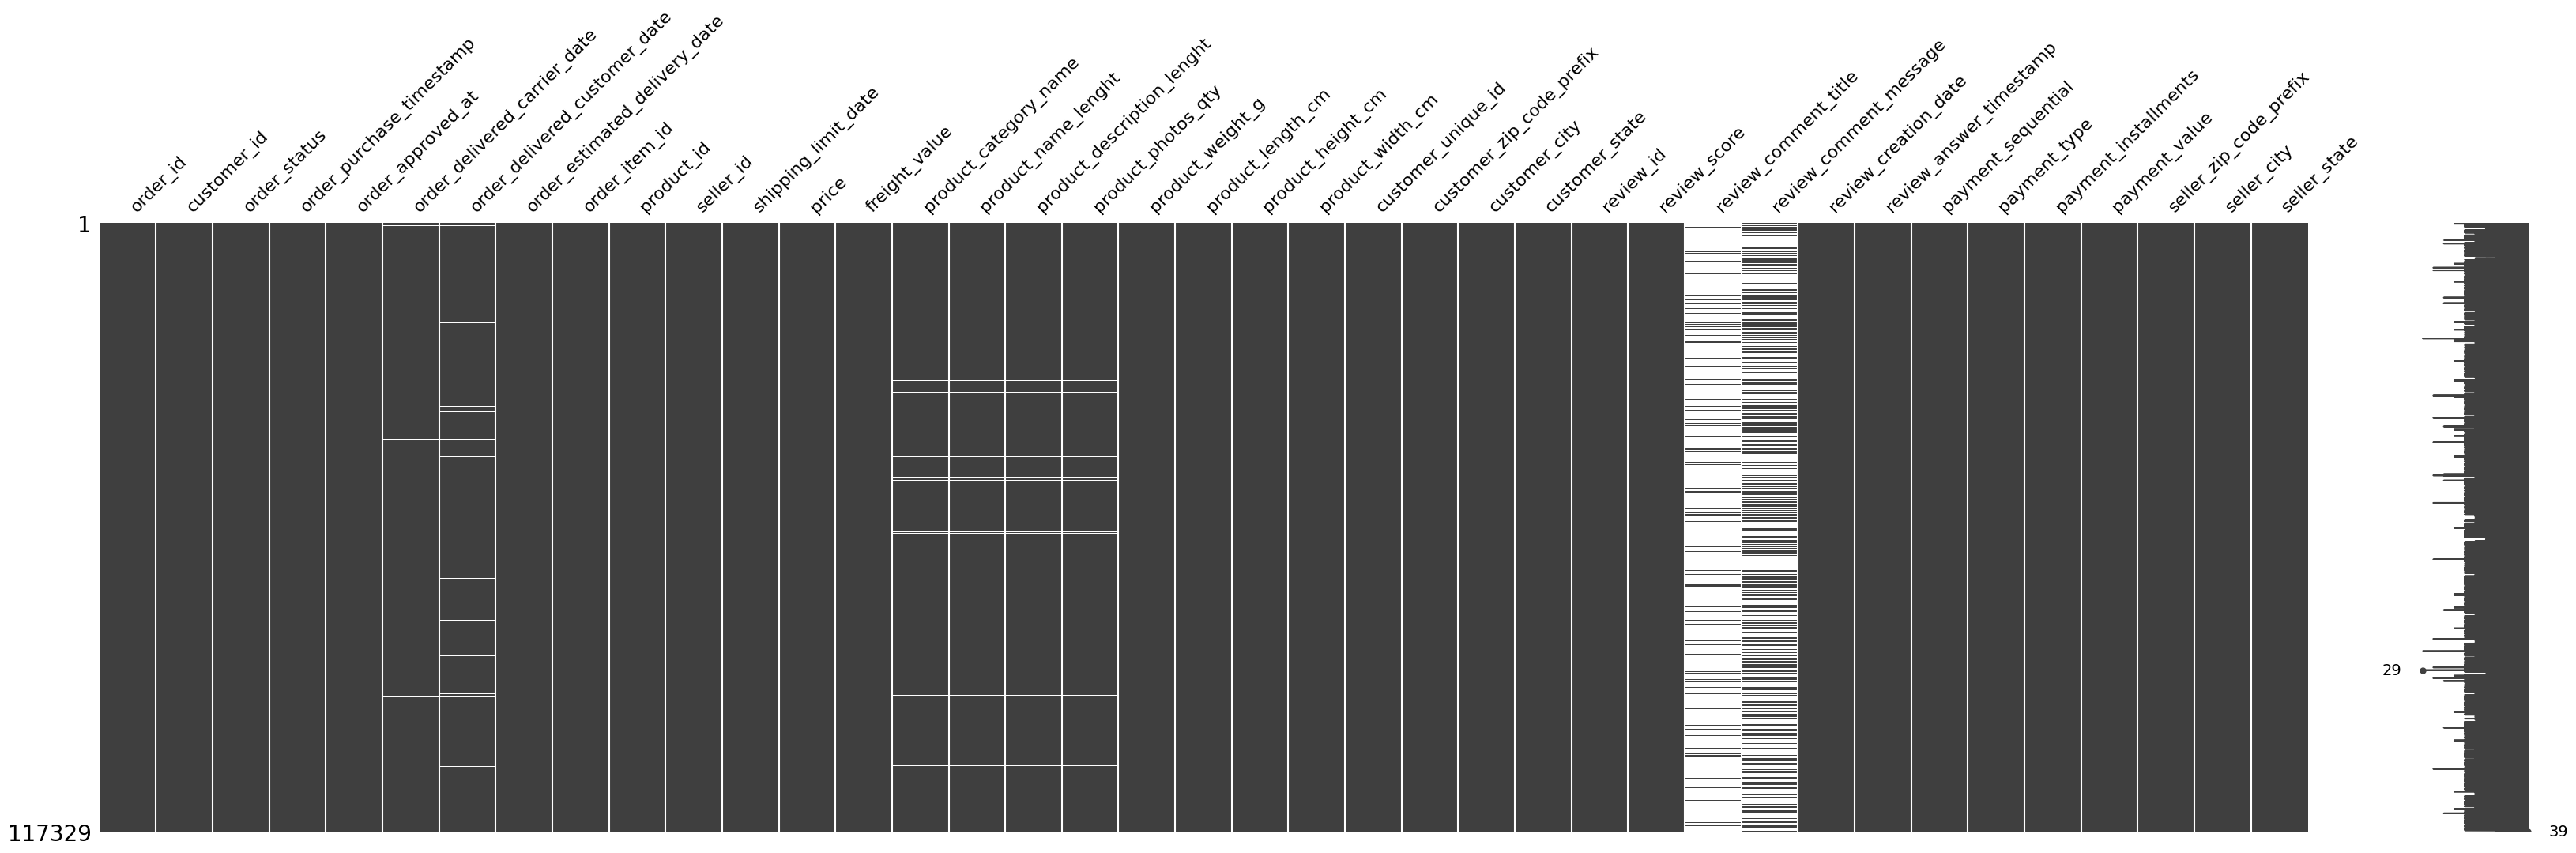

In [ ]:
# Maneira visual de verificar valores nulos nas diferentes variáveis do dataframe
missingno.matrix(df, figsize=(40,10))

In [ ]:
# Percentual de valores nulos

rows, columns = df.shape

percentual_nan = ((df.isnull().sum()/rows)*100).round(2)
percentual_nan

,0
order_id,0.00
customer_id,0.00
order_status,0.00
order_purchase_timestamp,0.00
order_approved_at,0.01
order_delivered_carrier_date,1.05
order_delivered_customer_date,2.11
order_estimated_delivery_date,0.00
order_item_id,0.00
product_id,0.00


In [ ]:
df[df.duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state


In [ ]:
# Contagem de valores distintos

contagem = pd.DataFrame(columns = ['Variavel', 'Quantidade_valores_distintos'])

for colunas in df.columns:
    dados = pd.DataFrame({'Variavel':[colunas], 'Quantidade_valores_distintos':df[colunas].value_counts().shape[0]})
    contagem = pd.concat([contagem, dados], ignore_index=True)

contagem

,Variavel,Quantidade_valores_distintos
0,order_id,97916
1,customer_id,97916
2,order_status,7
3,order_purchase_timestamp,97370
4,order_approved_at,89533
5,order_delivered_carrier_date,80449
6,order_delivered_customer_date,95021
7,order_estimated_delivery_date,449
8,order_item_id,21
9,product_id,32789


In [ ]:
# Funcionalidades da função dfSummary()
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,order_id[object],1. 895ab968e7bb0d5659d16cd74cd1652. fedcd9f7ccdc8cba3a18defedd1a553. fa65dad1b0e818e3ccc5cb0e3923134. ccf804e764ed5650cd8759557269dc5. a3725dfe487d359b5be08cac48b64e6. 68986e4324f6a21481df4e6e89abcf7. 465c2e1bee4561cb39e0db8c5993aa8. c6492b842ac190db807c15aff21a7d9. 6d58638e32674bebee793a47ac4cba10. 285c2e15bebd4ac83635ccc563dc7111. other,"63 (0.1%)38 (0.0%)29 (0.0%)26 (0.0%)24 (0.0%)24 (0.0%)24 (0.0%)24 (0.0%)24 (0.0%)22 (0.0%)117,031 (99.7%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAy5JREFUeJzt3MGN02AURtHnKIJhY2tkKSVADymCLb3ThTcwrMKCHq4lc04F/+JKT5H8ZXm9XgOF29kP4P8hNjJiIyM2MmIjIzYyYiMjNjJiIyM2MrdlWb4ty/J29kO4vtvMfJ2Zz2c/hOtzRsmIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNzG1mfs7Mn7MfwvUt/sWIijNKRmxkrKvIWFeRcUbJiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MgYvJAxeCHjjJIRGxmDFzIGL2ScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGRmxkrKvIWFeRcUbJiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MhYV5GxriLjjJIRGxmDFzIGL2ScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MhYV5GxriLjjJIRGxnrKjLWVWScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2MwQsZgxcyzigZsZERGxnrKjLWVWScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MtZVZKyryDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2MwQsZgxcyziiZZWa+zMynsx/C9d33ff++ruv72Q/h+u7rur4/n8/f27Z9nP0Yrus4jrf7zMy2bR+Px+PX2Q/i2vxAICM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiI3Of+ff5x9kP4dqO43hb9n3/4eNJCj4LJ2NdRcYPBDJiIyM2MmIjIzYyYiMjNjJiIyM2Mn8BY+dLgsx6ZCoAAAAASUVORK5CYII="">",0(0.0%)
2,customer_id[object],1. 270c23a11d024a44c896d1894b261a2. 13aa59158da63ba0e93ec6ac2c07aa3. 9af2372a1e49340278e7c1ef8d749f4. 92cd3ec6e2d643d4ebd0e3d6238f695. d22f25a9fadfb1abbc2e29395b12396. 86cc80fef09f7f39df4b0dbce48e817. 63b964e79dee32a3587651701a2b8d8. 6ee2f17e3b6c33d6a9557f280edd299. 2ba91e12e5e4c9f56b82b86d9031d310. b246eeed30b362c09d867b9e598bee11. other,"63 (0.1%)38 (0.0%)29 (0.0%)26 (0.0%)24 (0.0%)24 (0.0%)24 (0.0%)24 (0.0%)24 (0.0%)22 (0.0%)117,031 (99.7%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAy5JREFUeJzt3MGN02AURtHnKIJhY2tkKSVADymCLb3ThTcwrMKCHq4lc04F/+JKT5H8ZXm9XgOF29kP4P8hNjJiIyM2MmIjIzYyYiMjNjJiIyM2MrdlWb4ty/J29kO4vtvMfJ2Zz2c/hOtzRsmIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNzG1mfs7Mn7MfwvUt/sWIijNKRmxkrKvIWFeRcUbJiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MgYvJAxeCHjjJIRGxmDFzIGL2ScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGRmxkrKvIWFeRcUbJiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MhYV5GxriLjjJIRGxmDFzIGL2ScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MhYV5GxriLjjJIRGxnrKjLWVWScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2MwQsZgxcyzigZsZERGxnrKjLWVWScUTJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MtZVZKyryDijZMRGxuCFjMELGWeUjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2MwQsZgxcyziiZZWa+zMynsx/C9d33ff++ruv72Q/h+u7rur4/n8/f27Z9nP0Yrus4jrf7zMy2bR+Px+PX2Q/i2vxAICM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiI3Of+ff5x9kP4dqO43hb9n3/4eNJCj4LJ2NdRcYPBDJiIyM2MmIjIzYyYiMjNjJiIyM2Mn8BY+dLgsx6ZCoAAAAASUVORK5CYII="">",0(0.0%)
3,order_status[object],1. delivered2. shipped3. canceled4. invoiced5. processing6. unavailable7. approved,"114,859 (97.9%)1,167 (1.0%)553 (0.5%)370 (0.3%)370 (0.3%)7 (0.0%)3 (0.0%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAChCAYAAADQgM1HAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8v

# **Análise Exploratória de Dados (EDA)**

Nesta etapa, foi investigado a saúde da operação logística e o comportamento dos consumidores. O objetivo é entender as distribuições e identificar anomalias que possam afetar o treinamento do modelo.

In [ ]:
# Dataframe com a quantidade de pedidos para cada tipo de status do pedido

order_status_counts = df['order_status'].value_counts().reset_index()
order_status_counts.columns=['status_pedido','contagem']

order_status_counts

,status_pedido,contagem
0,delivered,114859
1,shipped,1167
2,canceled,553
3,invoiced,370
4,processing,370
5,unavailable,7
6,approved,3


A grande maioria dos pedidos (114.859) possui o status delivered. Isso indica uma base sólida de dados reais para prever o tempo e o custo de frete.

Pedidos cancelados ou indisponíveis representam uma fração mínima. Para o modelo de regressão, focaremos apenas nos pedidos entregues para evitar ruídos de operações não concluídas.

In [ ]:
# Dataframe com a quantidade de pedidos por tipo de pagamento

payment_counts = df['payment_type'].value_counts().reset_index()
payment_counts.columns=['Tipo_pagamento', 'contagem']

payment_counts

,Tipo_pagamento,contagem
0,credit_card,86520
1,boleto,22835
2,voucher,6282
3,debit_card,1692


In [ ]:
# Gráfico de barras mostrando a quantidade de pedidos por tipo de pagamento

fig = px.bar(payment_counts, x='Tipo_pagamento', y='contagem', color='Tipo_pagamento', text='contagem',
            title='Pedidos por tipo de pagamento', labels={'contagem':'Quantidade de Pedidos', 'Tipo_pagamento':'Tipo de Pagamento'})

fig.update_traces(textposition='outside', texttemplate='%{text}', textfont_size=12)
fig.update_layout(width=1000, height=500)
fig.show()

Liderança do cartão de crédito: Com mais de 86.000 pedidos, o cartão é o meio favorito, sugerindo um público que prioriza o parcelamento e a aprovação imediata do pedido.

Boleto como alternativa crítica: Sendo o segundo método mais usado (22.835), ele reforça a necessidade de considerar o tempo de compensação bancária na análise da velocidade de processamento logístico.

Uso de créditos: A presença de voucher e debit_card em menor escala mostra um ecossistema de pagamentos diversificado, permitindo futuras análises de retenção de clientes.

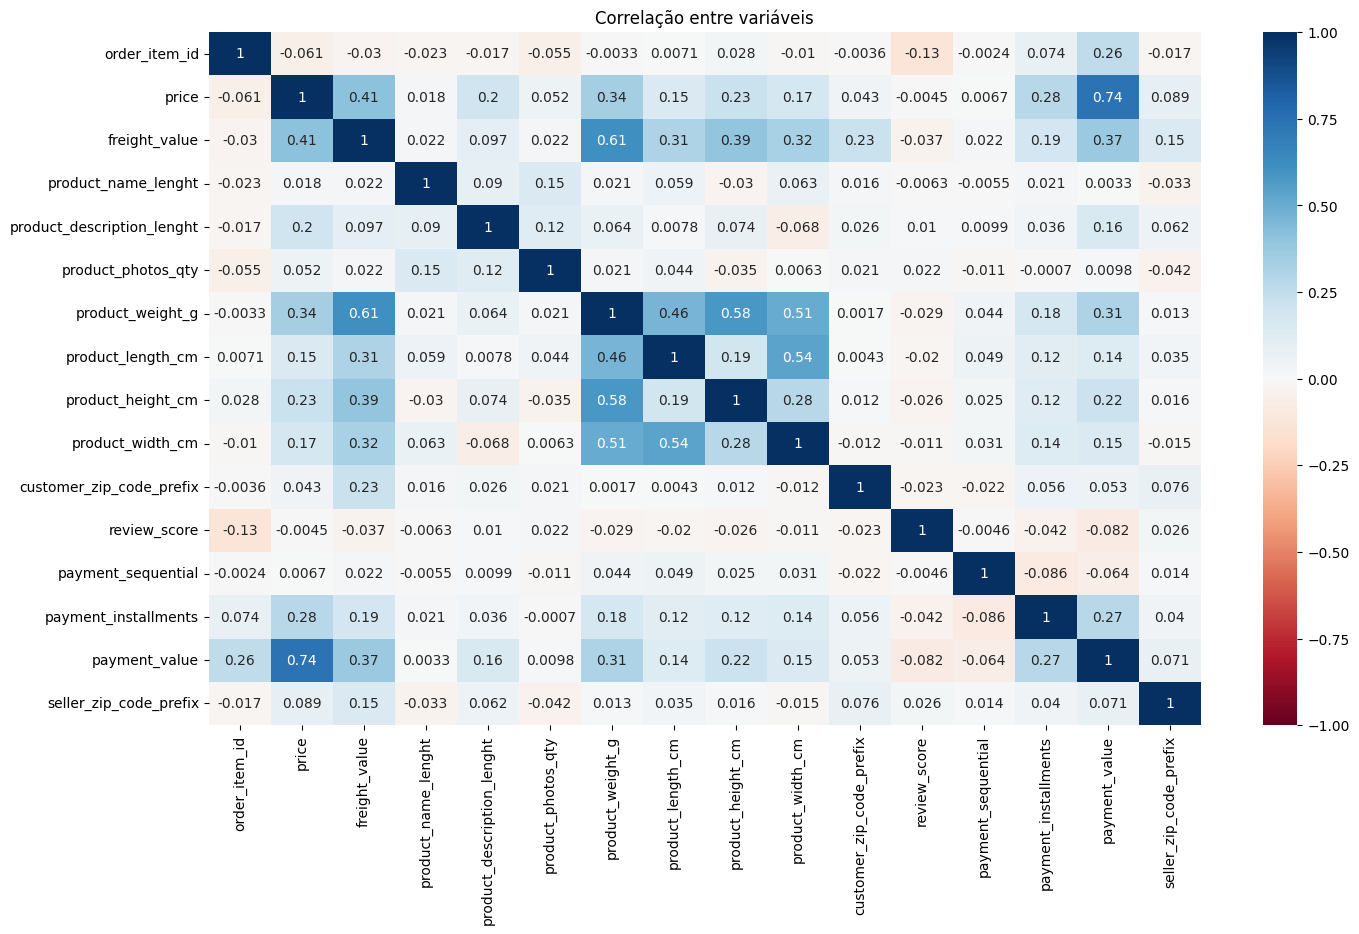

In [ ]:
# Heatmap mostrando as correlações entre variáveis numéricas

plt.figure(figsize=(16,9))
plt.title('Correlação entre variáveis')

df_numeric = df.select_dtypes(include=[np.number])
sns.heatmap(df_numeric.corr(), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.show()

Peso vs. Frete (0.61): o peso do produto (product_weight_g) apresenta a maior correlação positiva com o valor do frete. Quanto mais pesado o produto, maior o custo logístico.

Dimensões físicas: comprimento, altura e largura também apresentam correlações significativas (entre 0.31 e 0.39).

Preço vs. Pagamento (0.74): há uma forte correlação entre o preço do item e o valor total do pagamento, o que indica que taxas adicionais (como juros de parcelamento) não distorcem drasticamente a relação base de preço.

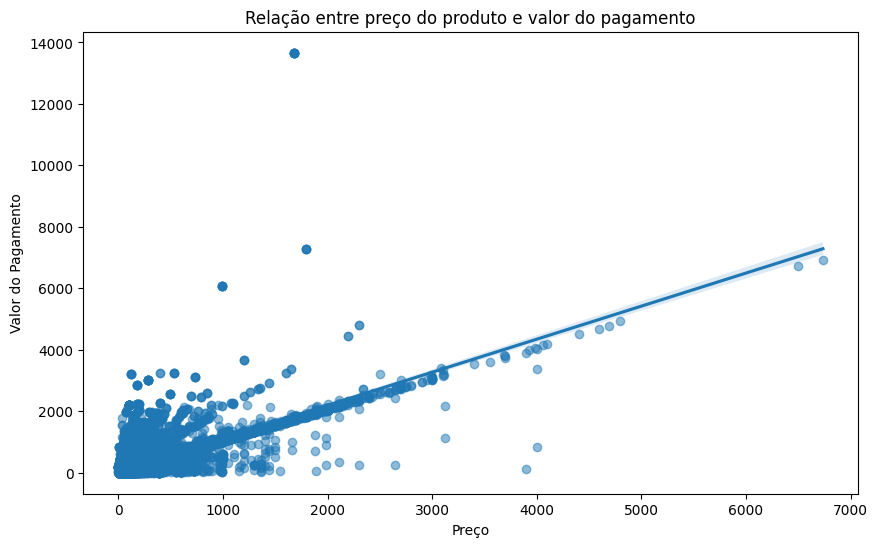

In [ ]:
# Gráfico de dispersão entre preço do produto e valor pago pelo cliente

plt.figure(figsize=(10,6))
sns.regplot(x='price', y='payment_value', data=df, scatter_kws={'alpha':0.5})

plt.title('Relação entre preço do produto e valor do pagamento')
plt.xlabel('Preço')
plt.ylabel('Valor do Pagamento')
plt.show()

O gráfico mostra uma tendência linear clara, mas identifica outliers extremos (pontos muito acima da linha).

Estes pontos representam casos onde o frete ou taxas adicionais foram desproporcionais ao preço. Analisaremos esses casos separadamente para decidir se devem ser removidos ou tratados para não prejudicar a precisão do modelo final.

In [ ]:
# analisando resultados que não fazem muito sentido, possível erro operacional/fraude
df[df['payment_value'] > 10000]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state
15717,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23 00:00:00,1,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,211fa81a22870cc634265ea85b751e40,1,NaN,"Peço por favor verificar a entrega do pedido, ...",2017-10-18 00:00:00,2017-10-19 13:10:39,1,credit_card,1,13664.08,3667,sao paulo,SP
15718,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23 00:00:00,2,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,211fa81a22870cc634265ea85b751e40,1,NaN,"Peço por favor verificar a entrega do pedido, ...",2017-10-18 00:00:00,2017-10-19 13:10:39,1,credit_card,1,13664.08,3667,sao paulo,SP
15719,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23 00:00:00,3,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,211fa81a22870cc634265ea85b751e40,1,NaN,"Peço por favor verificar a entrega do pedido, ...",2017-10-18 00:00:00,2017-10-19 13:10:39,1,credit_card,1,13664.08,3667,sao paulo,SP
15720,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23 00:00:00,4,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,211fa81a22870cc634265ea85b751e40,1,NaN,"Peço por favor verificar a entrega do pedido, ...",2017-10-18 00:00:00,2017-10-19 13:10:39,1,credit_card,1,13664.08,3667,sao paulo,SP
15721,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23 00:00:00,5,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,211fa81a22870cc634265ea85b751e40,1,NaN,"Peço por favor verificar a entrega do pedido, ...",2017-10-18 00:00:00,2017-10-19 13:10:39,1,credit_card,1,13664.08,3667,sao paulo,SP
15722,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23 00:00:00,6,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,211fa81a22870cc634265ea85b751e40,1,NaN,"Peço por favor verificar a entrega do 

([0], [Text(0, 0, '')])

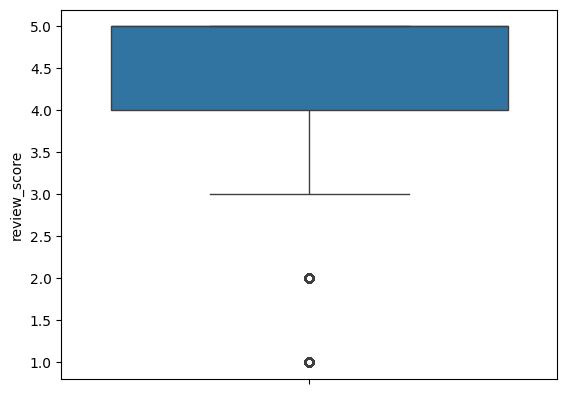

In [ ]:
# Análise univariada dos reviews dos clientes

fig=sns.boxplot(y='review_score', data=df)
plt.xticks(rotation=90)

A mediana das avaliações é 5.0, com a maior parte dos dados concentrada entre 4 e 5.
Os valores discrepantes (outliers) abaixo de 3 indicam entregas problemáticas que podem estar correlacionadas a fretes excessivamente caros ou prazos estourados.

In [ ]:
df['review_score'].describe()

,review_score
count,117329.000000
mean,4.031467
std,1.387927
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


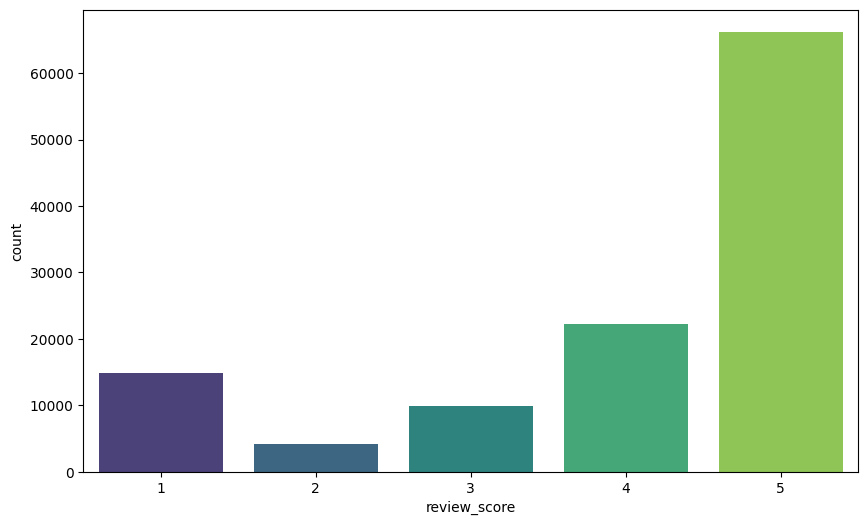

In [ ]:
# Countplot da quantidade de pedidos para cada uma das notas de review

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='review_score', palette='viridis')
plt.show()

A maioria das avaliações é nota 5.

A mediana das notas é alta, mas os outliers nos scores 1 e 2 indicam entregas problemáticas.

([0], [Text(0, 0, '')])

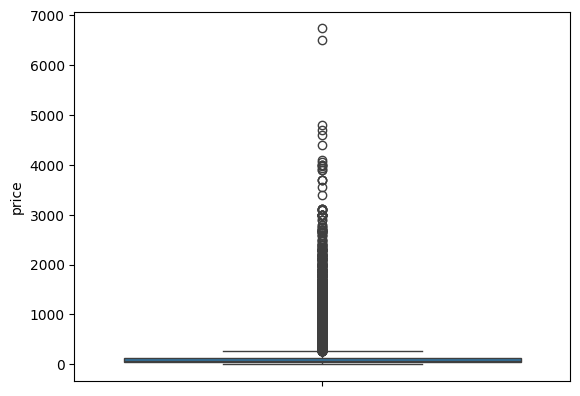

In [ ]:
# Análise univariada dos preços dos produtos

fig=sns.boxplot(y='price', data=df)
plt.xticks(rotation=90)

In [ ]:
df['price'].describe()

,price
count,117329.000000
mean,120.524349
std,182.944843
min,0.850000
25%,39.900000
50%,74.900000
75%,134.900000
max,6735.000000


Média vs. Mediana: a média de preço é de 120,52, mas a mediana (50%) é de apenas R$ 74,90. Essa diferença indica que produtos de altíssimo valor estão puxando a média para cima.

Outliers de Preço: o Boxplot mostra uma quantidade massiva de "pontos" acima do limite superior, chegando ao valor máximo de R$ 6.735,00.

Variabilidade: O desvio padrão (std) de 182,94 é maior que a própria média, confirmando que a Olist atende desde nichos de baixo custo até produtos de luxo.

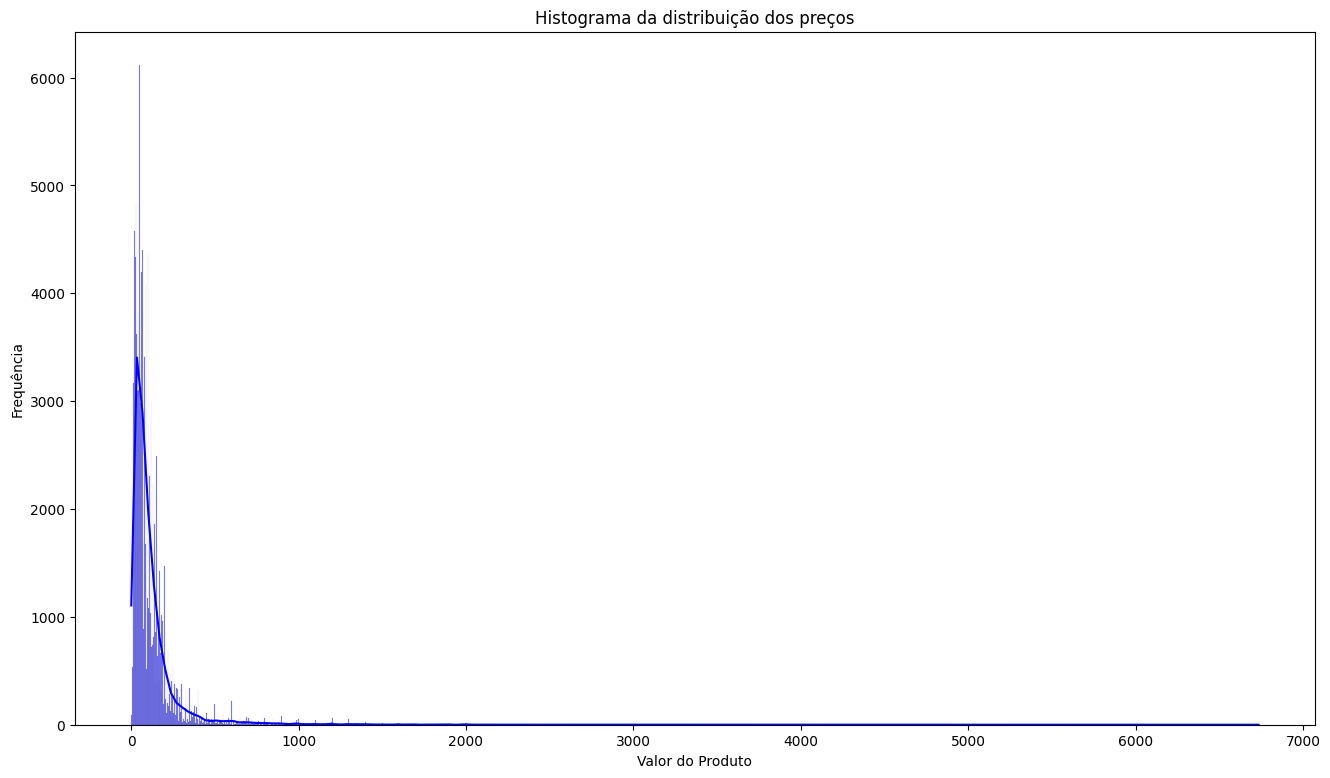

In [ ]:
# Histograma da distribuição dos preços dos produtos

plt.figure(figsize=(16,9))
sns.histplot(x='price', data=df, color='blue', kde=True)
plt.title('Histograma da distribuição dos preços')
plt.xlabel('Valor do Produto')
plt.ylabel('Frequência')
plt.show()

Assimetria Positiva (Skewed Right): o gráfico tem um "pico" muito alto próximo ao zero e uma cauda longa que se estende para a direita.

Concentração de Mercado: a grande maioria das vendas ocorre na faixa de 0 a 200. Para o negócio, isso significa que a estratégia logística deve ser otimizada para pacotes menores e mais frequentes, que compõem o grosso do faturamento.

([0], [Text(0, 0, '')])

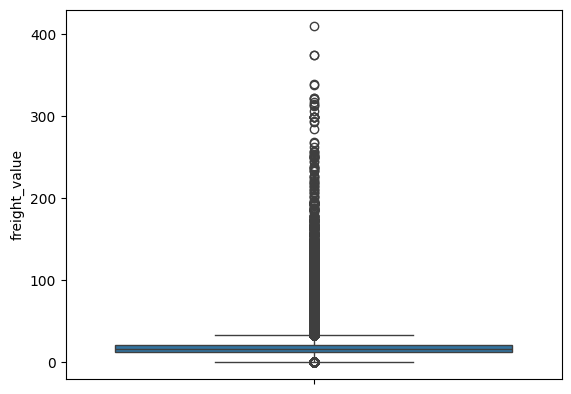

In [ ]:
# Análise univariada do valor do frete

fig=sns.boxplot(y='freight_value', data=df)
plt.xticks(rotation=90)

In [ ]:
df['freight_value'].describe()

,freight_value
count,117329.000000
mean,20.027514
std,15.828077
min,0.000000
25%,13.080000
50%,16.280000
75%,21.180000
max,409.680000


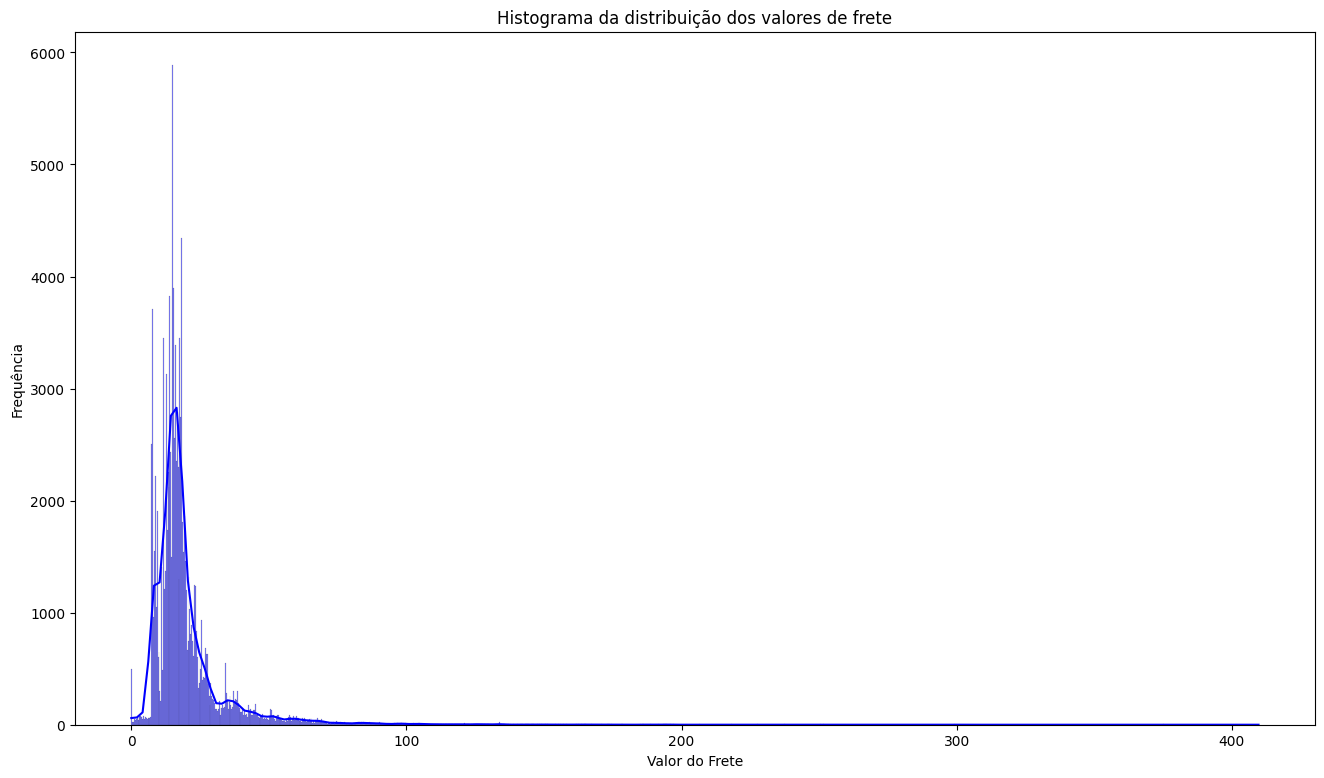

In [ ]:
# Histograma da distribuição de valores de frete

plt.figure(figsize=(16,9))
sns.histplot(x='freight_value', data=df, color='blue', kde=True)
plt.title('Histograma da distribuição dos valores de frete')
plt.xlabel('Valor do Frete')
plt.ylabel('Frequência')
plt.show()

Assimetria Positiva (Skewed Right): assim como os preços, o frete possui uma cauda longa à direita. A maioria esmagadora dos envios custa entre 10,00 e 30,00.

Pico de Densidade: existe um pico muito acentuado próximo aos 15,00, que representa a "zona de conforto" logística para pacotes padrão em rotas comuns.

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'delivered'),
  Text(1, 0, 'invoiced'),
  Text(2, 0, 'shipped'),
  Text(3, 0, 'processing'),
  Text(4, 0, 'canceled'),
  Text(5, 0, 'unavailable'),
  Text(6, 0, 'approved')])

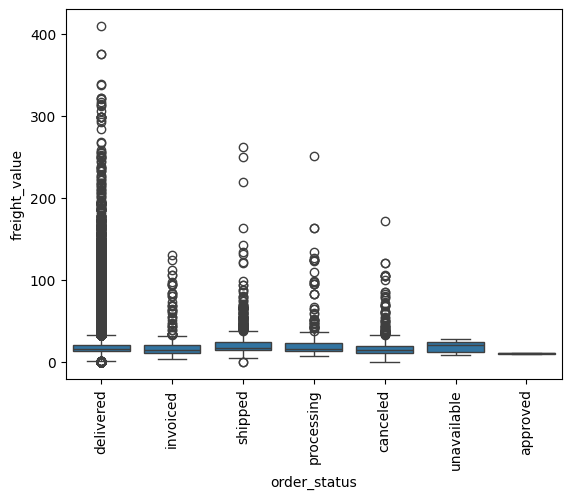

In [ ]:
fig=sns.boxplot(x = 'order_status',y='freight_value', data=df)
plt.xticks(rotation=90)

Consistência de custos: a mediana do valor do frete permanece relativamente constante em quase todas as categorias, sugerindo que o custo é calculado no checkout e não sofre grandes alterações contratuais após a postagem.

Outliers em entregas concluídas: o status delivered concentra a maior densidade de valores atípicos (outliers), com fretes atingindo o pico de R$ 409,68. Isso ocorre porque essa categoria contém o maior volume de dados (114.859 registros), capturando todas as variações de produtos pesados e entregas de longa distância.

Status de exceção: pedidos com status unavailable ou canceled ainda registram valores de frete associados. Para o seu modelo preditivo, é recomendável isolar esses casos, pois o custo logístico de um pedido que não foi concluído pode não refletir a realidade do mercado de fretes.

Estágio Inicial: o status approved apresenta a menor variabilidade, indicando pedidos recentes onde o frete ainda está em fase de processamento básico.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117329 non-null  object 
 1   customer_id                    117329 non-null  object 
 2   order_status                   117329 non-null  object 
 3   order_purchase_timestamp       117329 non-null  object 
 4   order_approved_at              117314 non-null  object 
 5   order_delivered_carrier_date   116094 non-null  object 
 6   order_delivered_customer_date  114858 non-null  object 
 7   order_estimated_delivery_date  117329 non-null  object 
 8   order_item_id                  117329 non-null  int64  
 9   product_id                     117329 non-null  object 
 10  seller_id                      117329 non-null  object 
 11  shipping_limit_date            117329 non-null  object 
 12  price                         

# **Engenharia de Variáveis (Feature Engineering)**

Em vez de usar apenas os dados brutos, métricas foram criadas para explicar melhor o custo logístico

In [ ]:
# Criando variavel do volume
df['Volume'] = df['product_length_cm']*df['product_height_cm']*df['product_width_cm']

In [ ]:
# Criando a variavel da densidade
df['densidade'] = df['product_weight_g']/df['Volume']

In [ ]:
# Criando coluna velocidade de entrega

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['Velocidade_entrega_real'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['Velocidade_entrega_estimada'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

In [ ]:
# Criação da velocidade de aprovação do pedido
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])

df['velocidade_processamento'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.days

In [ ]:
# base de geolocation
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
# Agregando as longitudes e latitudes pela média

geolocation_agregado = geolocation.groupby('geolocation_zip_code_prefix').agg({'geolocation_lat':'mean','geolocation_lng':'mean'}).reset_index()
geolocation_agregado.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [ ]:
# Trazendo latitude e longitude dos vendedores
df=pd.merge(df, geolocation_agregado, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state,Volume,densidade,Velocidade_entrega_real,Velocidade_entrega_estimada,velocidade_processamento,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,1,credit_card,1,18.12,9350,maua,SP,1976.0,0.253036,8.0,15,0.0,9350,-23.680729,-46.444238
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3,voucher,1,2.00,9350,maua,SP,1976.0,0.253036,8.0,15,0.0,9350,-23.680729,-46.444238
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2,voucher,1,18.59,9350,maua,SP,1976.0,0.253036,8.0,15,0.0,9350,-23.680729,-46.444238
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1,boleto,1,141.46,31570,belo horizonte,SP,4693.0,0.085233,13.0,19,1.0,31570,-19.807681,-43.980427
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1,credit_card,3,179.12,14840,guariba,SP,9576.0,0.043860,9.0,26,0.0,14840,-21.363502,-48.229601


In [ ]:
# Renomeando e excluindo colunas desnecessárias
df.rename(columns={'geolocation_lat':'seller_lat', 'geolocation_lng':'seller_lng'}, inplace=True)
df.drop(columns='geolocation_zip_code_prefix', inplace=True)

In [ ]:
# Trazendo latitude e longitude dos compradores
df=pd.merge(df, geolocation_agregado, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state,Volume,densidade,Velocidade_entrega_real,Velocidade_entrega_estimada,velocidade_processamento,seller_lat,seller_lng,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,1,credit_card,1,18.12,9350,maua,SP,1976.0,0.253036,8.0,15,0.0,-23.680729,-46.444238,3149,-23.576983,-46.587161
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3,voucher,1,2.00,9350,maua,SP,1976.0,0.253036,8.0,15,0.0,-23.680729,-46.444238,3149,-23.576983,-46.587161
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2,voucher,1,18.59,9350,maua,SP,1976.0,0.253036,8.0,15,0.0,-23.680729,-46.444238,3149,-23.576983,-46.587161
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1,boleto,1,141.46,31570,belo horizonte,SP,4693.0,0.085233,13.0,19,1.0,-19.807681,-43.980427,47813,-12.177924,-44.660711
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1,credit_card,3,179.12,14840,guariba,SP,9576.0,0.043860,9.0,26,0.0,-21.363502,-48.229601,75265,-16.745150,-48.514783


In [ ]:
# Renomeando e excluindo colunas desnecessárias
df.rename(columns={'geolocation_lat':'customer_lat', 'geolocation_lng':'customer_lng'}, inplace=True)
df.drop(columns='geolocation_zip_code_prefix', inplace=True)

In [ ]:
# Calculando a distância entre vendedor e comprador

def calcular_distancia(dataframe):
    seller_coordenadas = (dataframe['seller_lat'], dataframe['seller_lng'])
    customer_coordenadas = (dataframe['customer_lat'], dataframe['customer_lng'])

    return geodesic(seller_coordenadas, customer_coordenadas).kilometers

df['distancia'] = df.apply(calcular_distancia, axis=1)

In [ ]:
df.drop(columns=['seller_lat','seller_lng','customer_lat','customer_lng'], inplace=True)

In [ ]:
# Obtendo mês de compra e dia da semana da compra
df['mes_compra'] = df['order_purchase_timestamp'].dt.month

df['dia_semana_compra'] = df['order_purchase_timestamp'].dt.dayofweek

In [ ]:
# Trazendo informação da época do ano

df['black_friday'] = ((df['mes_compra'] == 11) & (df['dia_semana_compra'] == 4) & (df['order_purchase_timestamp'].dt.day >= 20) & (df['order_purchase_timestamp'].dt.day <= 30)).astype(int)
df['natal'] = ((df['mes_compra'] == 12) & (df['order_purchase_timestamp'].dt.day >= 1) & (df['order_purchase_timestamp'].dt.day <= 25)).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116750 entries, 0 to 116749
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       116750 non-null  object        
 1   customer_id                    116750 non-null  object        
 2   order_status                   116750 non-null  object        
 3   order_purchase_timestamp       116750 non-null  datetime64[ns]
 4   order_approved_at              116735 non-null  datetime64[ns]
 5   order_delivered_carrier_date   115525 non-null  object        
 6   order_delivered_customer_date  114296 non-null  datetime64[ns]
 7   order_estimated_delivery_date  116750 non-null  datetime64[ns]
 8   order_item_id                  116750 non-null  int64         
 9   product_id                     116750 non-null  object        
 10  seller_id                      116750 non-null  object        
 11  

In [ ]:
# Removendo as colunas desnecessárias
colunas_para_remover = ['order_id', 'customer_id', 'product_id', 'seller_id', 'order_status', 'order_purchase_timestamp',
                       'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',
                       'order_estimated_delivery_date', 'shipping_limit_date', 'product_description_lenght',
                       'product_name_lenght', 'product_photos_qty', 'customer_unique_id', 'review_id', 'review_comment_title',
                       'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'payment_sequential',
                       'payment_type', 'payment_installments', 'payment_value', 'seller_zip_code_prefix', 'order_item_id']

df.drop(columns=colunas_para_remover, inplace=True)

df.head()

,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix,customer_city,customer_state,review_score,seller_city,seller_state,Volume,densidade,Velocidade_entrega_real,Velocidade_entrega_estimada,velocidade_processamento,distancia,mes_compra,dia_semana_compra,black_friday,natal
0,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,3149,sao paulo,SP,4,maua,SP,1976.0,0.253036,8.0,15,0.0,18.566632,10,0,0,0
1,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,3149,sao paulo,SP,4,maua,SP,1976.0,0.253036,8.0,15,0.0,18.566632,10,0,0,0
2,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,3149,sao paulo,SP,4,maua,SP,1976.0,0.253036,8.0,15,0.0,18.566632,10,0,0,0
3,118.70,22.76,perfumaria,400.0,19.0,13.0,19.0,47813,barreiras,BA,4,belo horizonte,SP,4693.0,0.085233,13.0,19,1.0,847.437333,7,1,0,0
4,159.90,19.22,automotivo,420.0,24.0,19.0,21.0,75265,vianopolis,GO,5,guariba,SP,9576.0,0.043860,9.0,26,0.0,512.100044,8,2,0,0


In [ ]:
df.drop(columns='customer_zip_code_prefix', inplace=True)

In [ ]:
df[df.duplicated()]

,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_city,customer_state,review_score,seller_city,seller_state,Volume,densidade,Velocidade_entrega_real,Velocidade_entrega_estimada,velocidade_processamento,distancia,mes_compra,dia_semana_compra,black_friday,natal
1,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,sao paulo,SP,4,maua,SP,1976.0,0.253036,8.0,15,0.0,18.566632,10,0,0,0
2,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,sao paulo,SP,4,maua,SP,1976.0,0.253036,8.0,15,0.0,18.566632,10,0,0,0
12,149.99,19.77,moveis_escritorio,9750.0,42.0,41.0,42.0,sorocaba,SP,5,itaquaquecetuba,SP,72324.0,0.134810,18.0,24,0.0,112.448811,7,5,0,0
14,99.00,30.53,ferramentas_jardim,9000.0,42.0,12.0,39.0,rio de janeiro,RJ,1,cariacica,ES,19656.0,0.457875,12.0,21,0.0,414.429592,5,1,0,0
23,76.00,16.97,telefonia,325.0,19.0,8.0,22.0,feira de santana,BA,4,jacarei,SP,3344.0,0.097189,13.0,27,0.0,1430.183627,10,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116719,356.00,18.12,esporte_lazer,2800.0,28.0,23.0,23.0,sao paulo,SP,4,ribeirao preto,SP,14812.0,0.189036,12.0,20,0.0,297.390311,8,3,0,0
116738,42.11,0.80,brinquedos,600.0,48.0,10.0,48.0,cuiaba,MT,5,nova iguacu,RJ,23040.0,0.026042,16.0,33,0.0,1546.696507,10,2,0,0
116740,26.90,36.98,brinquedos,750.0,26.0,15.0,26.0,cuiaba,MT,5,nova iguacu,RJ,10140.0,0.073964,16.0,33,0.0,1546.696507,10,2,0,0
116742,370.00,19.43,beleza_saude,750.0,38.0,12.0,25.0,divinopolis,MG,5,curitiba,PR,11400.0,0.065789,11.0,48,0.0,744.051836,1,4,0,0


In [ ]:
# Excluindo linhas duplicadas
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101075 entries, 0 to 116749
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   price                        101075 non-null  float64
 1   freight_value                101075 non-null  float64
 2   product_category_name        99632 non-null   object 
 3   product_weight_g             101059 non-null  float64
 4   product_length_cm            101059 non-null  float64
 5   product_height_cm            101059 non-null  float64
 6   product_width_cm             101059 non-null  float64
 7   customer_city                101075 non-null  object 
 8   customer_state               101075 non-null  object 
 9   review_score                 101075 non-null  int64  
 10  seller_city                  101075 non-null  object 
 11  seller_state                 101075 non-null  object 
 12  Volume                       101059 non-null  float64
 13  dens

# **Modelagem e Validação Cruzada**

Para garantir a robustez, foi implementado um Pipeline de pré-processamento e teste de algoritmos.

In [ ]:
# Dividindo em X e y
X = df.drop(columns='freight_value', axis=1)
y = df.freight_value

In [ ]:
# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = 42)

In [ ]:
# Modelos instanciados

modelo_XGBoost = XGBRegressor(n_estimators = 1000, max_depth = 8, learning_rate = 1e-3, n_jobs = -1, random_state = 0)
modelo_LightGBM = LGBMRegressor(n_estimators = 1000, max_depth = 8, num_leaves = 2^8, learning_rate = 1e-3, n_jobs = -1, verbose = -1, random_state = 0)
modelo_catboost = CatBoostRegressor(n_estimators = 1000, max_depth = 8, learning_rate = 1e-3, random_state = 0, verbose = 0)
modelo_decision_tree = DecisionTreeRegressor(random_state = 0, max_depth = 8, min_samples_split = 2)

In [ ]:
# Aplicando o Feature importance

# Instanciando o catboost encoder para variáveis categóricas
encoder = CatBoostEncoder()

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

for col in X_train_encoded.select_dtypes(include=['object']).columns:

    # Tratando a variável categórica
    X_train_encoded[col] = encoder.fit_transform(X_train_encoded[col], y_train)
    X_test_encoded[col] = encoder.transform(X_test_encoded[col])

# Treinando o modelo
modelo_XGBoost.fit(X_train_encoded, y_train)

r = permutation_importance(modelo_XGBoost, X_test_encoded, y_test, n_repeats = 30, random_state = 0)

In [ ]:
# Criando um dataframe para mostrar as importâncias de cada variável
importances = pd.DataFrame({'Feature':X_test_encoded.columns, 'importance':r.importances_mean})

# Ordenando as variáveis pela importância
importances = importances.sort_values(by='importance', ascending=False)
importances

In [ ]:
# Definindo as colunas menos importantes com base no Feature Importance
colunas_menos_importantes = ['review_score', 'dia_semana_compra', 'natal', 'product_category_name', 'black_friday']

# Excluindo as colunas menos importantes
X_train = X_train.drop(columns = colunas_menos_importantes)
X_test = X_test.drop(columns = colunas_menos_importantes)

In [ ]:
# Aplicando o Feature importance

# Instanciando o catboost encoder para variáveis categóricas
encoder = CatBoostEncoder()

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

for col in X_train_encoded.select_dtypes(include=['object']).columns:

    # Tratando a variável categórica
    X_train_encoded[col] = encoder.fit_transform(X_train_encoded[col], y_train)
    X_test_encoded[col] = encoder.transform(X_test_encoded[col])

# Treinando o modelo
modelo_XGBoost.fit(X_train_encoded, y_train)

r_versao_2 = permutation_importance(modelo_XGBoost, X_test_encoded, y_test, n_repeats = 30, random_state = 0)

In [ ]:
# Criando um dataframe para mostrar as importâncias de cada variável
importances_2 = pd.DataFrame({'Feature':X_test_encoded.columns, 'importance':r_versao_2.importances_mean})

# Ordenando as variáveis pela importância
importances_2 = importances_2.sort_values(by='importance', ascending=False)
importances_2

In [ ]:
k = 5

folds = KFold(n_splits = k, shuffle = True, random_state = 42)

# Criando listas para armazenar os valores das métricas em cada fold
erros_absolutos = list()
erros_quadrados = list()
r2 = list()

# Será aplicado o método "split" no objeto folds, que retornará uma lista
# com os índices das instâncias que pertencem ao conjunto de treino e
# outra com os índices das instâncias que pertencem ao conjunto de teste

for k, (train_index, test_index) in enumerate(folds.split(X, y)):

    print("#-"*8 + f"Fold: {k+1}" + "-#"*8)

    # Dividindo os dados em treino e teste para cada um dos folds
    X_train_interno, y_train_interno = X.iloc[train_index, :], y.iloc[train_index]
    X_test_interno, y_test_interno = X.iloc[test_index, :], y.iloc[test_index]
    # train_index e test_index: São os índices das instâncias do conjunto
    # de treino e teste, respectivamente, selecionados em cada um dos folds

    # Instanciando o CatBoost Encoder
    encoder = CatBoostEncoder()

    # Criando um imputer para preencher com a moda os valores faltantes de variáveis categóricas
    cat_imputer = SimpleImputer(strategy='most_frequent')

    # Criando um imputer para preencher com a mediana os valores faltantes de variáveis numéricas
    num_imputer = SimpleImputer(strategy='median')

    # Criando pipelines para variáveis categóricas e numéricas que preenche os valores faltantes
    cat_pipeline = Pipeline([('encoder', encoder), ('imputer', cat_imputer)])
    num_pipeline = Pipeline([('imputer', num_imputer)])

    # Definindo quem são as variáveis categóricas e numéricas
    cat_cols = X_train_interno.select_dtypes(include=['object']).columns
    num_cols = X_train_interno.select_dtypes(exclude=['object']).columns

    # Aplicando os pipelines no conjunto de treinamento para preencher valores faltantes em colunas categóricas e numéricas
    X_train_interno[cat_cols] = cat_pipeline.fit_transform(X_train_interno[cat_cols], y_train_interno)
    X_train_interno[num_cols] = num_pipeline.fit_transform(X_train_interno[num_cols])

    # Aplicando os pipelines ao conjunto de teste para preencher valores faltantes em colunas categóricas e numéricas
    X_test_interno[cat_cols] = cat_pipeline.transform(X_test_interno[cat_cols])
    X_test_interno[num_cols] = num_pipeline.transform(X_test_interno[num_cols])

    # Treinando o modelo
    modelo_XGBoost.fit(X_train_interno, y_train_interno)

    # Obtendo as previsões do modelo
    y_pred = modelo_XGBoost.predict(X_test_interno)

    # Calculando as métricas para o fold em questão
    r2score = r2_score(y_test_interno, y_pred)
    mse = mean_squared_error(y_test_interno, y_pred)
    mae = mean_absolute_error(y_test_interno, y_pred)

    # Armazenando as métricas nas listas criadas
    erros_absolutos.append(mae)
    erros_quadrados.append(mse)
    r2.append(r2score)

    # Exibindo as métricas para cada um dos folds
    print(f"MAE: {mae:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"R2: {r2score:.3f}")

In [ ]:
# Inserir o cálculo das médias

# Transformando as listas erros_absolutos, erros_quadrados e r2 em arrays, para fazer operações matemática
erros_absolutos = np.array(erros_absolutos)
erros_quadrados = np.array(erros_quadrados)
r2 = np.array(r2)

# Calculando a média de todas as métricas
media_mae = np.mean(erros_absolutos)
media_mse = np.mean(erros_quadrados)
media_r2 = np.mean(r2)

# Calculando o desvio padrão de todas as métricas
std_mae = np.std(erros_absolutos)
std_mse = np.std(erros_quadrados)
std_r2 = np.std(r2)

print("#-"*6 + "Exibindo a média das métricas obtidas" + "-#"*6)
print(f"Média do MAE: {media_mae:.3f} +/- {std_mae:.3f}")
print(f"Média do MSE: {media_mse:.3f} +/- {std_mse:.3f}")
print(f"Média do R2: {media_r2:.3f} +/- {std_r2:.3f}")

In [ ]:
def validacao_cruzada(X, y, modelo, k):

    folds = KFold(n_splits = k, shuffle = True, random_state = 42)

    # Criando listas para armazenar os valores das métricas em cada fold
    erros_absolutos = list()
    erros_quadrados = list()
    r2 = list()

    # Será aplicado o método "split" no objeto folds, que retornará uma lista
    # com os índices das instâncias que pertencem ao conjunto de treino e
    # outra com os índices das instâncias que pertencem ao conjunto de teste
    for k, (train_index, test_index) in enumerate(folds.split(X, y)):

        print("#-"*8 + f"Fold: {k+1}" + "-#"*8)

        # Dividindo os dados em treino e teste para cada um dos folds
        X_train_interno, y_train_interno = X.iloc[train_index, :], y.iloc[train_index]
        X_test_interno, y_test_interno = X.iloc[test_index, :], y.iloc[test_index]
        # train_index e test_index: São os índices das instâncias do conjunto
        # de treino e teste, respectivamente, selecionados em cada um dos folds

        # Instanciando o CatBoost Encoder
        encoder = CatBoostEncoder()

        # Criando um imputer para preencher com a moda os valores faltantes de variáveis categóricas
        cat_imputer = SimpleImputer(strategy='most_frequent')

        # Criando um imputer para preencher com a mediana os valores faltantes de variáveis numéricas
        num_imputer = SimpleImputer(strategy='median')

        # Criando pipelines para variáveis categóricas e numéricas que preenche os valores faltantes
        cat_pipeline = Pipeline([('encoder', encoder), ('imputer', cat_imputer)])
        num_pipeline = Pipeline([('imputer', num_imputer)])

        # Definindo quem s"ao as variãveis num~ericas e categóricas
        cat_cols = X_train_interno.select_dtypes(include=['object']).columns
        num_cols = X_train_interno.select_dtypes(exclude=['object']).columns

        # Aplicando os pipelines no conjunto de treinamento para preencher valores faltantes em colunas categóricas e numéricas
        X_train_interno[cat_cols] = cat_pipeline.fit_transform(X_train_interno[cat_cols], y_train_interno)
        X_train_interno[num_cols] = num_pipeline.fit_transform(X_train_interno[num_cols])

        # Aplicando os pipelines ao conjunto de teste para preencher valores faltantes em colunas categóricas e numéricas
        X_test_interno[cat_cols] = cat_pipeline.transform(X_test_interno[cat_cols])
        X_test_interno[num_cols] = num_pipeline.transform(X_test_interno[num_cols])

        # Treinando o modelo
        modelo.fit(X_train_interno, y_train_interno)

        # Obtendo as previsões do modelo
        y_pred = modelo.predict(X_test_interno)

        # Calculando as métricas para o fold em questão
        r2score = r2_score(y_test_interno, y_pred)
        mse = mean_squared_error(y_test_interno, y_pred)
        mae = mean_absolute_error(y_test_interno, y_pred)

        # Armazenando as métricas nas listas criadas
        erros_absolutos.append(mae)
        erros_quadrados.append(mse)
        r2.append(r2score)

        # Exibindo as métricas para cada um dos folds
        print(f"MAE: {mae:.3f}")
        print(f"MSE: {mse:.3f}")
        print(f"R2: {r2score:.3f}")

    # Transformando as listas erros_absolutos, erros_quadrados e r2 em arrays, para fazer operações matemáticas
    erros_absolutos = np.array(erros_absolutos)
    erros_quadrados = np.array(erros_quadrados)
    r2 = np.array(r2)

    # Calculando a média de todas as métricas
    media_mae = np.mean(erros_absolutos)
    media_mse = np.mean(erros_quadrados)
    media_r2 = np.mean(r2)

    # Calculando o desvio padrão de todas as métricas
    std_mae = np.std(erros_absolutos)
    std_mse = np.std(erros_quadrados)
    std_r2 = np.std(r2)

    print("#-"*6 + "Exibindo a média das métricas obtidas" + "-#"*6)
    print(f"Média do MAE: {media_mae:.3f} +/- {std_mae:.3f}")
    print(f"Média do MSE: {media_mse:.3f} +/- {std_mse:.3f}")
    print(f"Média do R2: {media_r2:.3f} +/- {std_r2:.3f}")

# Modelo XGBoost

In [ ]:
validacao_cruzada(X, y, modelo_XGBoost, k=5)

# Modelo LightGBM

In [ ]:
validacao_cruzada(X, y, modelo_LightGBM, k=5)

# Modelo Catboost

In [ ]:
validacao_cruzada(X, y, modelo_catboost, k=5)

# Modelo Decision Tree

In [ ]:
validacao_cruzada(X, y, modelo_decision_tree, k=5)

# **Otimização de Hiperparâmetros (Fine-Tuning)**

In [ ]:
def tunagem_hiperparametros(trial, k=5):

    # Tunagem
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 1e-1, log=True)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    subsample = trial.suggest_float('subsample', 0.5, 1, step=0.1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1, step=0.1)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)

    folds = KFold(n_splits = k, shuffle = True, random_state = 42)

    # Criando listas para armazenar os valores das métricas em cada fold
    erros_absolutos = list()
    erros_quadrados = list()
    r2 = list()

    # Será aplicado o método "split" no objeto folds, que retornará uma lista
    # com os índices das instâncias que pertencem ao conjunto de treino e
    # outra com os índices das instâncias que pertencem ao conjunto de teste

    for k, (train_index, test_index) in enumerate(folds.split(X, y)):

        print("#-"*8 + f"Fold: {k+1}" + "-#"*8)

        # Dividindo os dados em treino e teste para cada um dos folds
        X_train_interno, y_train_interno = X.iloc[train_index, :], y.iloc[train_index]
        X_test_interno, y_test_interno = X.iloc[test_index, :], y.iloc[test_index]
        # train_index e test_index: São os índices das instâncias do conjunto
        # de treino e teste, respectivamente, selecionados em cada um dos folds

        # Instanciando o CatBoost Encoder
        encoder = CatBoostEncoder()

        # Criando um imputer para preencher com a moda os valores faltantes de variáveis categóricas
        cat_imputer = SimpleImputer(strategy='most_frequent')

        # Criando um imputer para preencher com a mediana os valores faltantes de variáveis numéricas
        num_imputer = SimpleImputer(strategy='median')

        # Criando pipelines para variáveis categóricas e numéricas que preenche os valores faltantes
        cat_pipeline = Pipeline([('encoder', encoder), ('imputer', cat_imputer)])
        num_pipeline = Pipeline([('imputer', num_imputer)])

        # cat_cols e num_cols são trazidos para cá para incluir as novas variáveis criadas no feature engineering
        cat_cols = X_train_interno.select_dtypes(include=['object']).columns
        num_cols = X_train_interno.select_dtypes(exclude=['object']).columns

        # Aplicando os pipelines no conjunto de treinamento para preencher valores faltantes em colunas categóricas e numéricas
        X_train_interno[cat_cols] = cat_pipeline.fit_transform(X_train_interno[cat_cols], y_train_interno)
        X_train_interno[num_cols] = num_pipeline.fit_transform(X_train_interno[num_cols])

        # Aplicando os pipelines ao conjunto de teste para preencher valores faltantes em colunas categóricas e numéricas
        X_test_interno[cat_cols] = cat_pipeline.transform(X_test_interno[cat_cols])
        X_test_interno[num_cols] = num_pipeline.transform(X_test_interno[num_cols])

        # Treinando o modelo
        modelo_XGBoost.fit(X_train_interno, y_train_interno)

        # Obtendo as previsões do modelo
        y_pred = modelo_XGBoost.predict(X_test_interno)

        # Calculando as métricas para o fold em questão
        r2score = r2_score(y_test_interno, y_pred)
        mse = mean_squared_error(y_test_interno, y_pred)
        mae = mean_absolute_error(y_test_interno, y_pred)

        # Armazenando as métricas nas listas criadas
        erros_absolutos.append(mae)
        erros_quadrados.append(mse)
        r2.append(r2score)

    # Transformando as listas erros_absolutos, erros_quadrados e r2 em arrays, para fazer operações matemáticas
    erros_absolutos = np.array(erros_absolutos)
    erros_quadrados = np.array(erros_quadrados)
    r2 = np.array(r2)

    # Calculando a média de todas as métricas
    media_mae = np.mean(erros_absolutos)
    media_mse = np.mean(erros_quadrados)
    media_r2 = np.mean(r2)

    # Calculando o desvio padrão de todas as métricas
    std_mae = np.std(erros_absolutos)
    std_mse = np.std(erros_quadrados)
    std_r2 = np.std(r2)

    return media_mse

study = opt.create_study(direction='minimize')
study.optimize(tunagem_hiperparametros, n_trials = 20)

[I 2026-01-23 19:57:41,901] A new study created in memory with name: no-name-f19407a5-9db1-4b6d-94ea-d3e3943ec749


#-#-#-#-#-#-#-#-Fold: 1-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 2-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 3-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 4-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 5-#-#-#-#-#-#-#-#


[I 2026-01-23 20:00:09,750] Trial 0 finished with value: 100.96271617963595 and parameters: {'learning_rate': 0.02056164426131179, 'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 8}. Best is trial 0 with value: 100.96271617963595.


#-#-#-#-#-#-#-#-Fold: 1-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 2-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 3-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 4-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 5-#-#-#-#-#-#-#-#


[I 2026-01-23 20:02:38,361] Trial 1 finished with value: 100.96271617963595 and parameters: {'learning_rate': 0.0011710327105483227, 'max_depth': 6, 'subsample': 0.5, 'colsample_bytree': 0.7, 'min_child_weight': 2}. Best is trial 0 with value: 100.96271617963595.


...

[I 2026-01-23 20:41:48,984] Trial 17 finished with value: 100.96271617963595 and parameters: {'learning_rate': 0.020690733116367738, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.9, 'min_child_weight': 8}. Best is trial 0 with value: 100.96271617963595.


#-#-#-#-#-#-#-#-Fold: 1-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 2-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 3-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 4-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 5-#-#-#-#-#-#-#-#


[I 2026-01-23 20:44:15,501] Trial 18 finished with value: 100.96271617963595 and parameters: {'learning_rate': 0.002024143818226024, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_weight': 6}. Best is trial 0 with value: 100.96271617963595.


#-#-#-#-#-#-#-#-Fold: 1-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 2-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 3-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 4-#-#-#-#-#-#-#-#
#-#-#-#-#-#-#-#-Fold: 5-#-#-#-#-#-#-#-#


[I 2026-01-23 20:46:40,671] Trial 19 finished with value: 100.96271617963595 and parameters: {'learning_rate': 0.04433854975118747, 'max_depth': 4, 'subsample': 0.5, 'colsample_bytree': 0.8, 'min_child_weight': 4}. Best is trial 0 with value: 100.96271617963595.


In [ ]:
params = {'learning_rate': 0.013812820207934165, 'max_depth': 8, 'subsample': 0.5, 'colsample_bytree': 0.6, 'min_child_weight': 8}

In [ ]:
modelo_XGBoost = XGBRegressor(n_estimators = 1000, n_jobs=-1, random_state=0, **params)

In [ ]:
validacao_cruzada(X, y, modelo_XGBoost, k=5)

#-#-#-#-#-#-#-#-Fold: 1-#-#-#-#-#-#-#-#
MAE: 3.490
MSE: 59.078
R2: 0.760
#-#-#-#-#-#-#-#-Fold: 2-#-#-#-#-#-#-#-#
MAE: 3.626
MSE: 61.732
R2: 0.767
#-#-#-#-#-#-#-#-Fold: 3-#-#-#-#-#-#-#-#
MAE: 3.525
MSE: 56.259
R2: 0.773
#-#-#-#-#-#-#-#-Fold: 4-#-#-#-#-#-#-#-#
MAE: 3.539
MSE: 66.995
R2: 0.753
#-#-#-#-#-#-#-#-Fold: 5-#-#-#-#-#-#-#-#
MAE: 3.485
MSE: 50.305
R2: 0.785
#-#-#-#-#-#-Exibindo a média das métricas obtidas-#-#-#-#-#-#
Média do MAE: 3.533 +/- 0.051
Média do MSE: 58.874 +/- 5.557
Média do R2: 0.767 +/- 0.011


In [ ]:
def feature_engineering(X_train, X_test):
    # Criação da variável volume

    X_train['Volume'] = X_train['product_length_cm']*X_train['product_height_cm']*X_train['product_width_cm']
    X_test['Volume'] = X_test['product_length_cm']*X_test['product_height_cm']*X_test['product_width_cm']

    # Criação da variavel ...

    return X_train, X_test

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101075 entries, 0 to 116749
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   price                        101075 non-null  float64
 1   freight_value                101075 non-null  float64
 2   product_category_name        99632 non-null   object 
 3   product_weight_g             101059 non-null  float64
 4   product_length_cm            101059 non-null  float64
 5   product_height_cm            101059 non-null  float64
 6   product_width_cm             101059 non-null  float64
 7   customer_city                101075 non-null  object 
 8   customer_state               101075 non-null  object 
 9   review_score                 101075 non-null  int64  
 10  seller_city                  101075 non-null  object 
 11  seller_state                 101075 non-null  object 
 12  Volume                       101059 non-null  float64
 13  dens

In [ ]:
def validacao_cruzada(X, y, modelo, k):

    folds = KFold(n_splits = k, shuffle = True, random_state = 42)

    # Criando listas para armazenar os valores das métricas em cada fold
    erros_absolutos = list()
    erros_quadrados = list()
    r2 = list()

    # Será aplicado o método "split" no objeto folds, que retornará uma lista
    # com os índices das instâncias que pertencem ao conjunto de treino e
    # outra com os índices das instâncias que pertencem ao conjunto de teste

    for k, (train_index, test_index) in enumerate(folds.split(X, y)):

        print("#-"*8 + f"Fold: {k+1}" + "-#"*8)

        # Dividindo os dados em treino e teste para cada um dos folds
        X_train_interno, y_train_interno = X.iloc[train_index, :], y.iloc[train_index]
        X_test_interno, y_test_interno = X.iloc[test_index, :], y.iloc[test_index]

        # Instanciando o CatBoost Encoder
        encoder = CatBoostEncoder()

        # Criando um imputer para preencher com a moda os valores faltantes de variáveis categóricas
        cat_imputer = SimpleImputer(strategy='most_frequent')

        # Criando um imputer para preencher com a mediana os valores faltantes de variáveis numéricas
        num_imputer = SimpleImputer(strategy='median')

        # Criando pipelines para variáveis categóricas e numéricas que preenche os valores faltantes
        cat_pipeline = Pipeline([('encoder', encoder), ('imputer', cat_imputer)])
        num_pipeline = Pipeline([('imputer', num_imputer)])

        ############# Feature Engineering
        X_train_interno, X_test_interno = feature_engineering(X_train_interno, X_test_interno)

        # cat_cols e num_cols são trazidos para cá para incluir as novas variáveis criadas no feature engineering
        cat_cols = X_train_interno.select_dtypes(include=['object']).columns
        num_cols = X_train_interno.select_dtypes(exclude=['object']).columns

        # Aplicando os pipelines no conjunto de treinamento para preencher valores faltantes em colunas categóricas e numéricas
        X_train_interno[cat_cols] = cat_pipeline.fit_transform(X_train_interno[cat_cols], y_train_interno)
        X_train_interno[num_cols] = num_pipeline.fit_transform(X_train_interno[num_cols])

        # Aplicando os pipelines ao conjunto de teste para preencher valores faltantes em colunas categóricas e numéricas
        X_test_interno[cat_cols] = cat_pipeline.transform(X_test_interno[cat_cols])
        X_test_interno[num_cols] = num_pipeline.transform(X_test_interno[num_cols])

        # Treinando o modelo
        modelo.fit(X_train_interno, y_train_interno)

        # Obtendo as previsões do modelo
        y_pred = modelo.predict(X_test_interno)

        # Calculando as métricas para o fold em questão
        r2score = r2_score(y_test_interno, y_pred)
        mse = mean_squared_error(y_test_interno, y_pred)
        mae = mean_absolute_error(y_test_interno, y_pred)

        # Armazenando as métricas nas listas criadas
        erros_absolutos.append(mae)
        erros_quadrados.append(mse)
        r2.append(r2score)

        # Exibindo as métricas para cada um dos folds
        print(f"MAE: {mae:.3f}")
        print(f"MSE: {mse:.3f}")
        print(f"R2: {r2score:.3f}")

    # Transformando as listas erros_absolutos, erros_quadrados e r2 em arrays, para fazer operações matemáticas
    erros_absolutos = np.array(erros_absolutos)
    erros_quadrados = np.array(erros_quadrados)
    r2 = np.array(r2)

    # Calculando a média de todas as métricas
    media_mae = np.mean(erros_absolutos)
    media_mse = np.mean(erros_quadrados)
    media_r2 = np.mean(r2)

    # Calculando o desvio padrão de todas as métricas
    std_mae = np.std(erros_absolutos)
    std_mse = np.std(erros_quadrados)
    std_r2 = np.std(r2)

    # Exibindo a média das métricas obtidas
    print("#-"*6 + "Exibindo a média das métricas obtidas" + "-#"*6)
    print(f"Média do MAE: {media_mae:.3f} +/- {std_mae:.3f}")
    print(f"Média do MSE: {media_mse:.3f} +/- {std_mse:.3f}")
    print(f"Média do R2: {media_r2:.3f} +/- {std_r2:.3f}")

In [ ]:
validacao_cruzada(X, y, modelo_LightGBM, k=5)

#-#-#-#-#-#-#-#-Fold: 1-#-#-#-#-#-#-#-#
MAE: 5.664
MSE: 120.227
R2: 0.511
#-#-#-#-#-#-#-#-Fold: 2-#-#-#-#-#-#-#-#
MAE: 5.827
MSE: 128.344
R2: 0.515
#-#-#-#-#-#-#-#-Fold: 3-#-#-#-#-#-#-#-#
MAE: 5.773
MSE: 119.646
R2: 0.517
#-#-#-#-#-#-#-#-Fold: 4-#-#-#-#-#-#-#-#
MAE: 5.715
MSE: 136.550
R2: 0.497
#-#-#-#-#-#-#-#-Fold: 5-#-#-#-#-#-#-#-#
MAE: 5.612
MSE: 108.576
R2: 0.535
#-#-#-#-#-#-Exibindo a média das métricas obtidas-#-#-#-#-#-#
Média do MAE: 5.718 +/- 0.076
Média do MSE: 122.669 +/- 9.366
Média do R2: 0.515 +/- 0.012


# **Resultados Finais**

O modelo consegue explicar 60% da variabilidade do valor do frete. O erro médio absoluto (MAE) de R$ 5,21 indica que, em média, nossas previsões estão muito próximas do valor real, permitindo que a empresa faça simulações de frete mais seguras para novos vendedores ou novos produtos.